# Exercise 8 — CH3 
This exercise explores the relationship between mpg (miles per gallon) and horsepower in the Auto dataset using simple linear regression.
We proceed in three parts:
* (a) Fit a linear model via sm.OLS() with mpg as response and horsepower as predictor. Assess whether a statistically significant relationship exists, its strength and direction, and compute predicted values with confidence/prediction intervals at horsepower = 98.
* (b) Visualize the data as a scatterplot with the least squares regression line overlaid.
* (c) Examine diagnostic plots (residuals vs. fitted, Q-Q, scale-location) to check the assumptions of the linear model and identify potential issues with the fit.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:

auto = pd.read_csv("../datasets/Auto.data", na_values=["?"], delim_whitespace=True)
auto.head()

/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_68369/3173444840.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto = pd.read_csv("../datasets/Auto.data", na_values=["?"], delim_whitespace=True)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [9]:
auto = auto.dropna()
y = auto['mpg']
X = MS(['horsepower']).fit_transform(auto)
model1 = sm.OLS(y, X)
result1 = model1.fit()
summarize(result1)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [35]:
# Goodness of the fit 
RSE = np.sqrt(result1.scale) # tells us the the standard deviation of the residual in our model 
print('RSE = {0}'.format(RSE))
R2 = result1.rsquared # tells us the fraction of the variance that can be explained by our model 
print('R^2: = {0}'.format(R2)) 

RSE = 4.90575691954594
R^2: = 0.6059482578894348


In [33]:
new_horsepower = pd.DataFrame({'horsepower':[98]})
newX = MS(['horsepower']).fit_transform(new_horsepower)
prediction = result1.get_prediction(newX)
print(prediction.predicted_mean)
print('Confidence interval {0}'.format(prediction.conf_int(alpha=0.05)))
print('Observation interval {0}'.format(prediction.conf_int(obs=True,alpha=0.05)))

[24.46707715]
Confidence interval [[23.97307896 24.96107534]]
Observation interval [[14.80939607 34.12475823]]


/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_68369/3344414410.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result1.params[0],
/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_68369/3344414410.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result1.params[1],


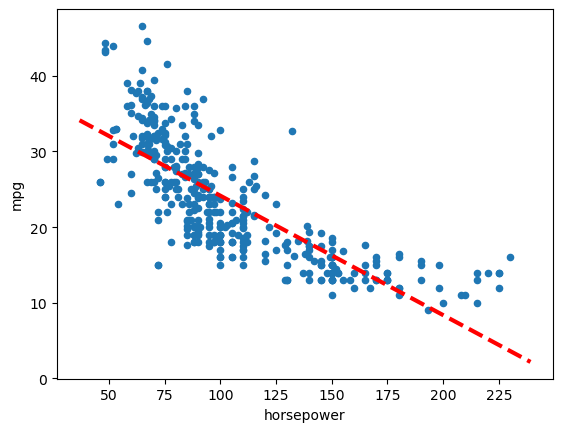

In [37]:
def abline(ax,b,m,*args,**kwargs):
    xlim = ax.get_xlim()
    ylim = [xlim[0]*m + b,xlim[1]*m +b]
    ax.plot(xlim,ylim,*args,**kwargs)

ax = auto.plot.scatter('horsepower','mpg')
abline(ax,
    result1.params[0],
    result1.params[1],
    'r--',
    linewidth = 3)


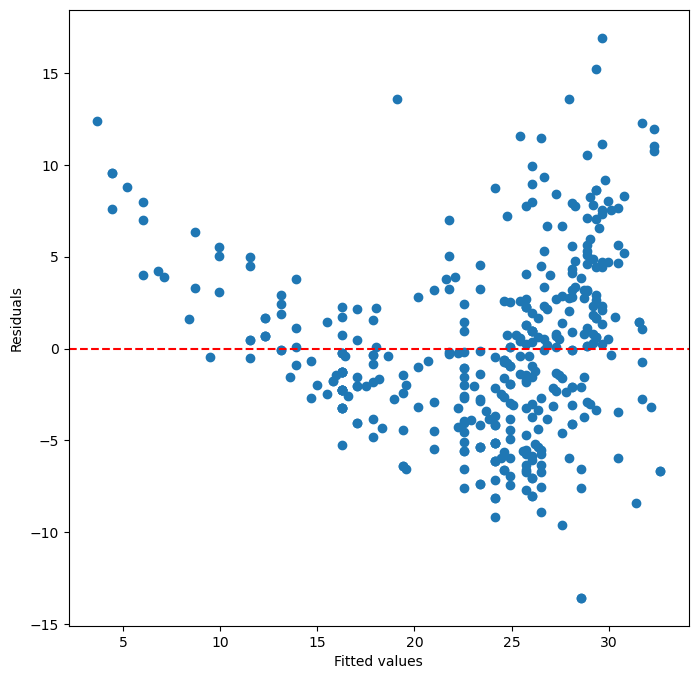

In [39]:
# Residual 
ax = subplots(figsize=(8,8))[1]
ax.scatter(result1.fittedvalues,result1.resid)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.axhline(0,c="r",ls="--");

We observe a U shape of the residual. If the data were distribute linearly our model would have predicted uniformly distributed residual. This is the hallmark of non linear relations between X and y. 

Text(0, 0.5, 'Leverage')

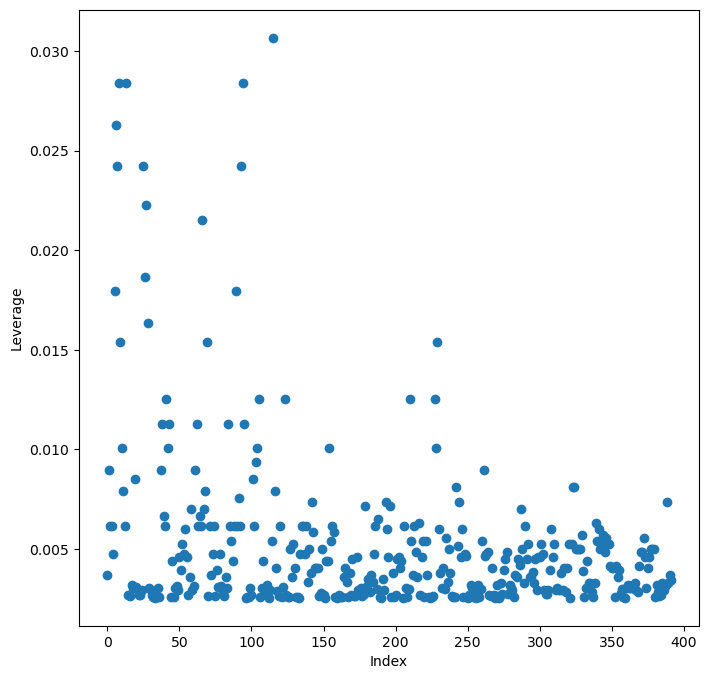

In [45]:
influence = result1.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]),influence.hat_diag_factor)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')



Text(0, 0.5, "Cook's Distance")

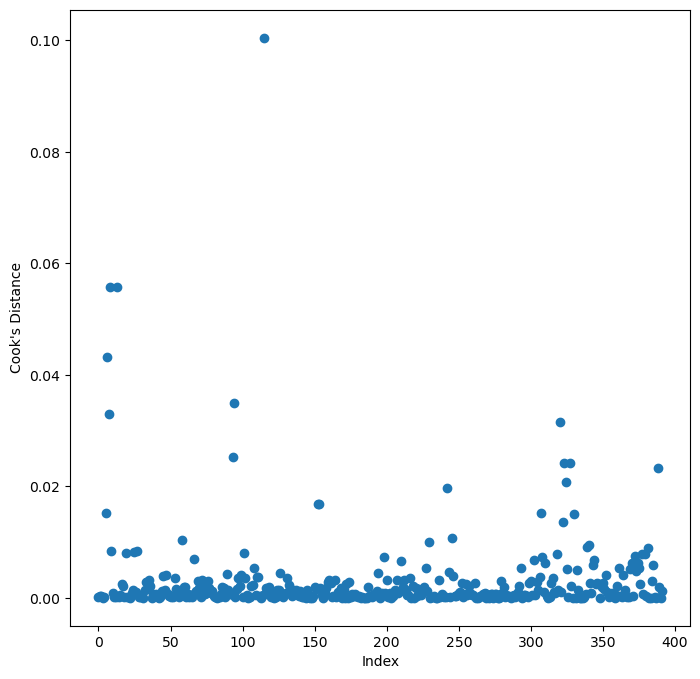

In [49]:
# Cook's DIstance 
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), influence.cooks_distance[0])
ax.set_xlabel('Index')
ax.set_ylabel('Cook\'s Distance')

Cook's distance quantify the influence of a data point combining both its leverage and residual. 
* Low Leverage, Low Residual - Not a problem 
* High Leverage, Low Residual - Not a problem 
* Low Leverage, High Residual - Not a problem 
* High Leverage, High Residual - It's a problem -> Check Cook's distance 